In [35]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34331,Workers: 16
Dashboard: http://127.0.0.1:8787/status,Total threads: 128
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:33083,Total threads: 8
Dashboard: http://127.0.0.1:43545/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:33057,


In [30]:
import numpy as np
import h5py
from datetime import datetime, timedelta
import cmocean.cm as cmo

# === Define time handling (mimic MATLAB datenum differences) ===
format_in = "%d.%m.%Y"

def days_since_ref(date_str, ref_str="01.01.1993"):
    """Return number of days between date_str and ref_str."""
    date = datetime.strptime(date_str, format_in)
    ref = datetime.strptime(ref_str, format_in)
    return (date - ref).days

# === Read MATLAB v7.3 HDF5 file ===
SSH_aviso_filename = "/data/SO6/TPOSE/constraints/aviso/aviso_tot_MSLA_eqpac.mat"

with h5py.File(SSH_aviso_filename, "r") as f:
    dsave = np.array(f["dsave"]).transpose(2,1,0) # time, y, x
    ysave = np.array(f["ysave"]).squeeze()
    xsave = np.array(f["xsave"]).squeeze()

# Compute start and end days
AV_startDay = days_since_ref("01.09.2012")
AV_endDay   = days_since_ref("31.12.2012")
SSH_AV = dsave[AV_startDay:AV_endDay+1, :, :]  # +1 because Python slices exclude end

In [31]:
SSH_AV.shape

(122, 228, 756)

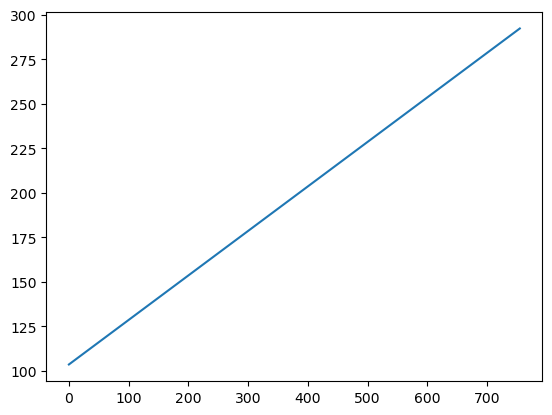

In [32]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
ax.plot(range(len(xsave.squeeze())),xsave.squeeze())

In [40]:
import xarray as xr
# === Build time coordinate ===
t0 = datetime.strptime("01.01.1993", format_in)
time = np.array([t0 + timedelta(days=int(d)) for d in range(AV_startDay, AV_endDay+1)])

# === Create xarray DataArray ===
SSH_da = xr.DataArray(
    SSH_AV,
    dims=["time", "YC", "XC"],
    coords={"time": time, "YC": ysave, "XC": xsave},
    name="SSH_AV"
)

# === Add attributes (optional) ===
SSH_da.attrs["description"] = "AVISO Mean Sea Level Anomaly (MSLA)"
SSH_da.attrs["units"] = "m"

# # === Save to NetCDF file (optional) ===
# SSH_da.to_netcdf("SSH_AVISO_eqpac_2012_10.nc")

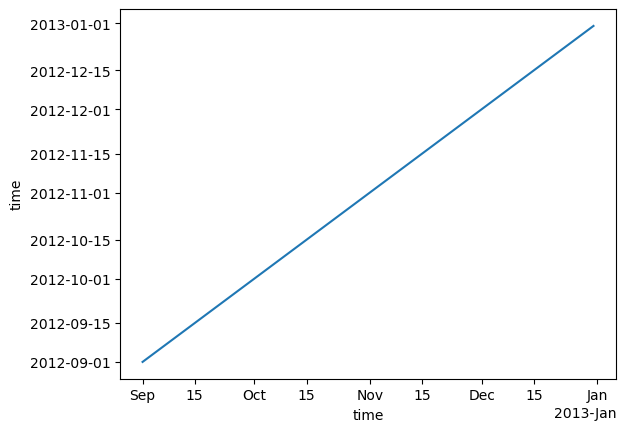

In [34]:
SSH_da.time.plot()

In [36]:
from xmitgcm import open_mdsdataset

foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/sep2012/fit_to_obs/compare_iter0_iter22/'
iter = 14
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_withhold/run_iter14/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags+1,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

iter = 22
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
ds_vel = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds_vel['XC'] = ds_vel.XC.astype(float)
ds_vel['YC'] = ds_vel.YC.astype(float)
ds_vel['Z'] = ds_vel.Z.astype(float)
ds_vel['XG'] = ds_vel.XG.astype(float)
ds_vel['YG'] = ds_vel.YG.astype(float)

In [43]:
ETAN_interp = ds.ETAN.interp_like(SSH_da,method='linear').compute()
ETAN_interp_vel = ds_vel.ETAN.interp_like(SSH_da,method='linear').compute()

In [44]:
rms_ssh = np.sqrt(((ETAN_interp - SSH_da)**2).mean(dim='time')).compute()
rms_ssh_1 = np.sqrt(((ETAN_interp.isel(time=slice(0,62)).compute() - SSH_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()
rms_ssh_2 = np.sqrt(((ETAN_interp.isel(time=slice(62,None)).compute() - SSH_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()

rms_ssh_vel = np.sqrt(((ETAN_interp_vel.compute() - SSH_da)**2).mean(dim='time')).compute()
rms_ssh_vel_1 = np.sqrt(((ETAN_interp_vel.isel(time=slice(0,62)).compute() - SSH_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()
rms_ssh_vel_2 = np.sqrt(((ETAN_interp_vel.isel(time=slice(62,None)).compute() - SSH_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()

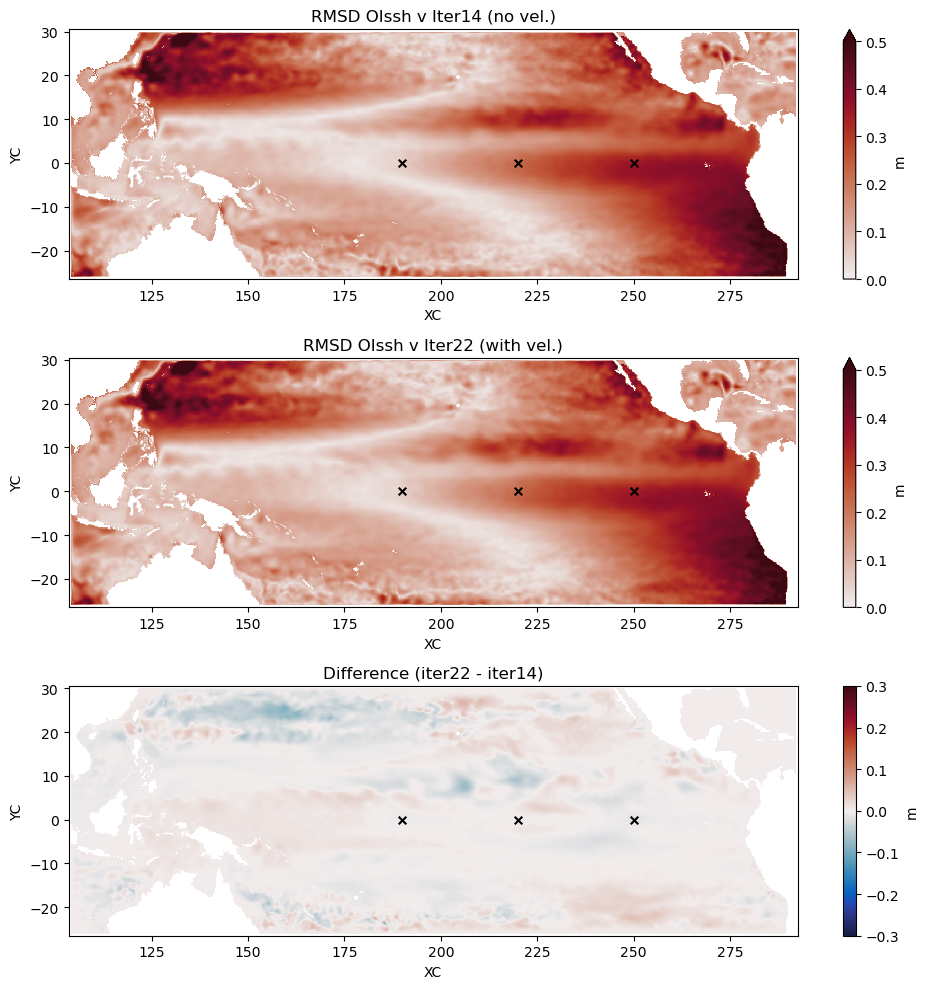

In [47]:
TAO_lon = np.array([190.0, 220.0, 250.0])
TAO_lat = np.array([0.0, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(10,10),nrows=3)
rms_ssh.plot(ax=ax[0],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0].set_title('RMSD OIssh v Iter14 (no vel.)')

rms_ssh_vel.plot(ax=ax[1],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1].set_title('RMSD OIssh v Iter22 (with vel.)')

(rms_ssh_vel - rms_ssh).plot(ax=ax[2],vmin=-0.3,vmax=0.3,cmap=cmo.balance,cbar_kwargs={'label':'m'})
ax[2].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[2].set_title('Difference (iter22 - iter14)')

plt.tight_layout()
fig.savefig(foldername + 'RMSD_aviso_vel_withhold.png')

In [48]:
client.shutdown()
cluster.close()
client.close()